In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [2]:
df = pd.read_csv("ai_developer_productivity.csv")

In [3]:
df.head(50)

,Developer_ID,Date,Hours_Coding,AI_Usage_Hours,Lines_of_Code,Commits,Bugs_Reported,Sleep_Hours,Distractions,Cognitive_Load,Stress_Level,Task_Success
0,DEV-126,2026-01-12,4.5,3.8,638,5,4,6,3,6,6,0
1,DEV-155,2026-01-12,2.7,3.5,438,0,4,3,8,8,8,0
2,DEV-199,2026-02-03,7.9,2.0,680,4,3,8,2,2,2,1
3,DEV-180,2026-01-13,3.1,7.9,765,1,5,8,4,3,5,0
4,DEV-144,2026-03-29,5.9,2.7,495,3,8,5,7,9,9,0
5,DEV-134,2026-02-21,7.6,1.2,429,5,1,8,1,4,2,1
6,DEV-134,2026-03-29,5.0,1.9,534,2,3,8,2,3,5,1
7,DEV-196,2026-03-05,5.4,2.7,669,5,2,7,3,5,4,1
8,DEV-134,2026-01-02,5.4,3.5,585,6,4,7,3,5,5,1
9,DEV-133,2026-01-28,2.1,1.8,243,2,4,5,9,9,10,0


In [7]:
df.isna().sum()

Developer_ID      0
Date              0
Hours_Coding      0
AI_Usage_Hours    0
Lines_of_Code     0
Commits           0
Bugs_Reported     0
Sleep_Hours       0
Distractions      0
Cognitive_Load    0
Stress_Level      0
Task_Success      0
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours_Coding    1000 non-null   float64
 1   AI_Usage_Hours  1000 non-null   float64
 2   Lines_of_Code   1000 non-null   int64  
 3   Commits         1000 non-null   int64  
 4   Bugs_Reported   1000 non-null   int64  
 5   Sleep_Hours     1000 non-null   int64  
 6   Distractions    1000 non-null   int64  
 7   Cognitive_Load  1000 non-null   int64  
 8   Stress_Level    1000 non-null   int64  
 9   Task_Success    1000 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 78.3 KB


In [21]:
df.describe()

,Hours_Coding,AI_Usage_Hours,Lines_of_Code,Commits,Bugs_Reported,Sleep_Hours,Distractions,Cognitive_Load,Stress_Level,Task_Success
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.985200,3.626300,639.462000,3.556000,3.685000,6.506000,4.105000,5.705000,5.464000,0.472000
std,1.392257,1.921919,253.068711,2.284312,2.737018,1.704368,2.663657,2.190153,2.124905,0.499465
min,2.000000,0.500000,132.000000,0.000000,0.000000,3.000000,0.000000,2.000000,2.000000,0.000000
25%,4.000000,2.200000,454.000000,2.000000,2.000000,5.000000,2.000000,4.000000,4.000000,0.000000
50%,4.900000,3.200000,596.000000,4.000000,3.000000,7.000000,4.000000,5.000000,5.000000,0.000000
75%,5.925000,5.000000,776.500000,5.000000,5.000000,8.000000,6.000000,7.000000,7.000000,1.000000
max,8.000000,8.000000,1450.000000,9.000000,20.000000,9.000000,10.000000,10.000000,10.000000,1.000000


In [8]:
df = df.drop(columns = ["Developer_ID", "Date"])

In [10]:
df.head(50)

,Hours_Coding,AI_Usage_Hours,Lines_of_Code,Commits,Bugs_Reported,Sleep_Hours,Distractions,Cognitive_Load,Stress_Level,Task_Success
0,4.5,3.8,638,5,4,6,3,6,6,0
1,2.7,3.5,438,0,4,3,8,8,8,0
2,7.9,2.0,680,4,3,8,2,2,2,1
3,3.1,7.9,765,1,5,8,4,3,5,0
4,5.9,2.7,495,3,8,5,7,9,9,0
5,7.6,1.2,429,5,1,8,1,4,2,1
6,5.0,1.9,534,2,3,8,2,3,5,1
7,5.4,2.7,669,5,2,7,3,5,4,1
8,5.4,3.5,585,6,4,7,3,5,5,1
9,2.1,1.8,243,2,4,5,9,9,10,0


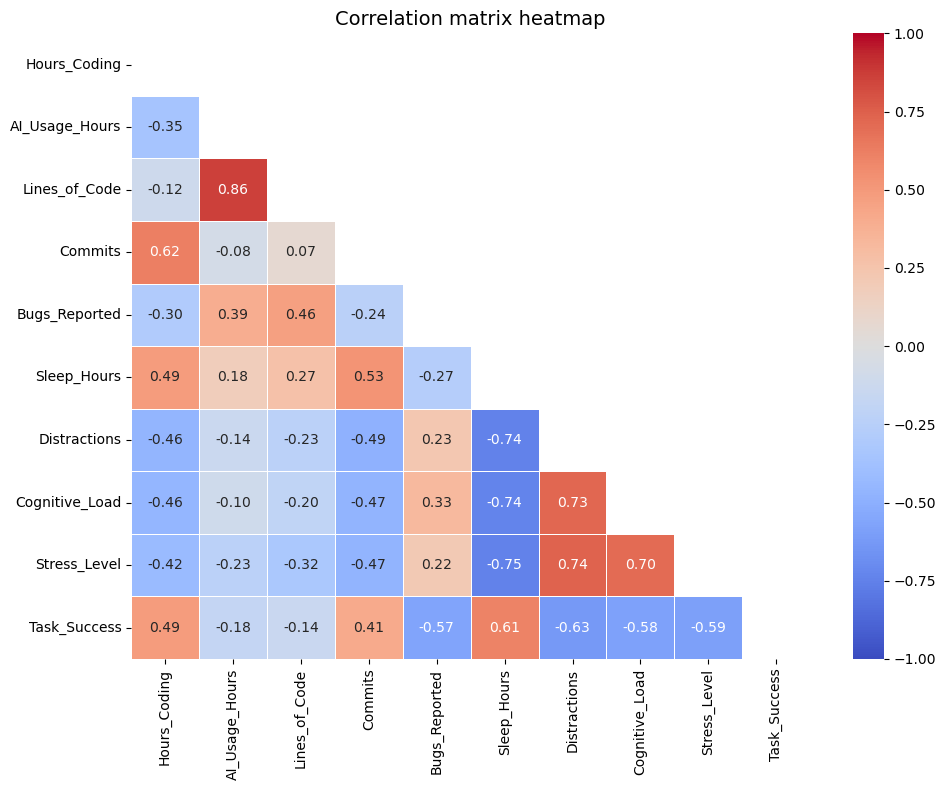

Pairs with |r| ≥ 0.8:
        var_1          var_2  correlation
Lines_of_Code AI_Usage_Hours      0.86061


In [17]:
# Compute Pearson correlation matrix
corr_matrix = df.corr(method="pearson")

# Mask the upper triangle (optional — removes redundancy)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation matrix heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# Flag high correlations (|r| > 0.8)
threshold = 0.8
high_corr = (
    corr_matrix.abs()
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["var_1", "var_2", "correlation"]
high_corr = high_corr[high_corr["correlation"].abs() >= threshold].sort_values(
    "correlation", ascending=False
)
print(f"Pairs with |r| ≥ {threshold}:")
print(high_corr.to_string(index=False))


Variance Inflation Factors:
       feature      VIF
 Lines_of_Code 5.575570
AI_Usage_Hours 5.520424
   Sleep_Hours 3.455250
  Distractions 3.222688
  Stress_Level 3.165772
Cognitive_Load 2.875387
  Task_Success 2.775460
  Hours_Coding 2.546387
 Bugs_Reported 2.022841
       Commits 1.854419


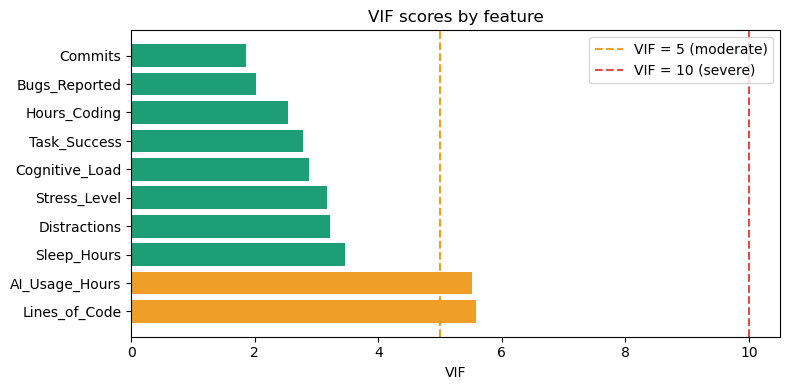

In [18]:
# VIF measures how much each variable is explained by the others.
# VIF > 5 → moderate collinearity; VIF > 10 → severe collinearity.

X = add_constant(df)

vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# Drop the constant row — not meaningful to report
vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)

print("\nVariance Inflation Factors:")
print(vif_data.to_string(index=False))

# Visual: bar chart of VIF scores
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e24b4a" if v >= 10 else "#ef9f27" if v >= 5 else "#1d9e75"
          for v in vif_data["VIF"]]
ax.barh(vif_data["feature"], vif_data["VIF"], color=colors)
ax.axvline(5,  color="#ef9f27", linestyle="--", label="VIF = 5 (moderate)")
ax.axvline(10, color="#e24b4a", linestyle="--", label="VIF = 10 (severe)")
ax.set_xlabel("VIF")
ax.set_title("VIF scores by feature")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# Condition number > 30 suggests multicollinearity; > 100 is severe.

X_scaled = (df - df.mean()) / df.std()
eigenvalues = np.linalg.eigvalsh(X_scaled.T @ X_scaled)
condition_number = np.sqrt(eigenvalues.max() / eigenvalues.clip(min=1e-10).min())

print(f"\nCondition number: {condition_number:.2f}")
if condition_number > 100:
    print("  → Severe multicollinearity detected")
elif condition_number > 30:
    print("  → Moderate multicollinearity — investigate further")
else:
    print("  → No significant multicollinearity")


Condition number: 7.07
  → No significant multicollinearity


In [24]:
from sklearn.model_selection import train_test_split

y = df['Task_Success']
X = df.drop(columns=['Task_Success'])

X_train, X_temp, y_train, y_temp = train_test_split(
X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# stratify= preserves class ratio in each split

In [25]:
# Prep Data for modeling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 'most_frequent' always predicts the majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

print("=== Dummy classifier ===")
print(classification_report(y_val, y_pred_dummy))
# Note: ROC-AUC is 0.5 by definition for a dummy — that's the point

=== Dummy classifier ===
              precision    recall  f1-score   support

           0       0.53      1.00      0.69        79
           1       0.00      0.00      0.00        71

    accuracy                           0.53       150
   macro avg       0.26      0.50      0.34       150
weighted avg       0.28      0.53      0.36       150



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# max_iter=1000 avoids convergence warnings on most datasets
# class_weight='balanced' handles imbalance automatically
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_val)
y_prob_lr  = lr.predict_proba(X_val)[:, 1]

print("=== Logistic regression ===")
print(classification_report(y_val, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_lr):.3f}")

=== Logistic regression ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        79
           1       0.97      0.97      0.97        71

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150

ROC-AUC: 0.998


In [28]:
# See which features push toward 1 (positive) vs 0 (negative)
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df.to_string(index=False))

# Red flag: if a coefficient direction contradicts domain knowledge,
# check for leakage, encoding errors, or collinearity

       feature  coefficient
   Sleep_Hours     1.230328
  Hours_Coding     0.256393
AI_Usage_Hours     0.065176
       Commits     0.052815
 Lines_of_Code    -0.000830
Cognitive_Load    -0.120380
  Distractions    -1.703859
  Stress_Level    -1.809721
 Bugs_Reported    -4.097667


In [29]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

def score_model(name, y_true, y_pred, y_prob=None):
    row = {
        'model':    name,
        'accuracy': round(accuracy_score(y_true, y_pred), 3),
        'f1':       round(f1_score(y_true, y_pred, zero_division=0), 3),
        'roc_auc':  round(roc_auc_score(y_true, y_prob), 3) if y_prob is not None else '—'
    }
    return row

results = [
    score_model('Dummy',        y_val, y_pred_dummy),
    score_model('Logistic reg.', y_val, y_pred_lr, y_prob_lr),
]

print(pd.DataFrame(results).to_string(index=False))
# Add rows here as you train XGBoost, Random Forest, etc.

        model  accuracy    f1 roc_auc
        Dummy     0.527 0.000       —
Logistic reg.     0.973 0.972   0.998


       feature  coefficient
 Bugs_Reported    -4.097667
  Stress_Level    -1.809721
  Distractions    -1.703859
   Sleep_Hours     1.230328
  Hours_Coding     0.256393
Cognitive_Load    -0.120380
AI_Usage_Hours     0.065176
       Commits     0.052815
 Lines_of_Code    -0.000830


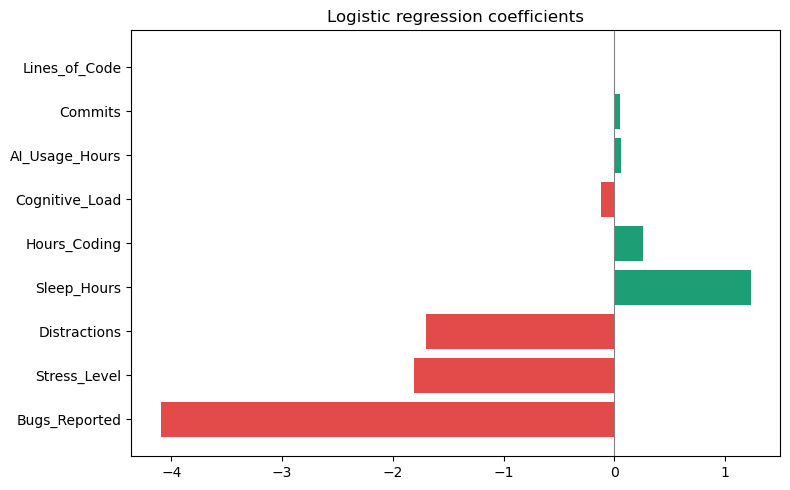

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Coefficients show direction AND magnitude
coef_df = pd.DataFrame({
    'feature':     X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=lambda x: x.abs(), ascending=False)

print(coef_df.to_string(index=False))

# Plot: positive = pushes toward 1, negative = pushes toward 0
colors = ['#1D9E75' if c > 0 else '#E24B4A' for c in coef_df['coefficient']]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Logistic regression coefficients')
plt.tight_layout()
plt.show()

# Green = feature increases predicted probability of 1
# Red   = feature decreases predicted probability of 1

In [31]:
from sklearn.inspection import permutation_importance

# Shuffles each feature and measures how much performance drops
# Works on ANY model — not just logistic regression
perm = permutation_importance(
    lr, X_val, y_val,
    n_repeats=30,       # shuffle each feature 30 times for stability
    scoring='roc_auc', # or 'f1' — use whatever metric you care about
    random_state=42
)

perm_df = pd.DataFrame({
    'feature':    X_val.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

print(perm_df.to_string(index=False))

# Features with importance near 0 or negative can safely be dropped
drop_candidates = perm_df[perm_df['importance'] <= 0]['feature'].tolist()
print(f"\nSafe to drop: {drop_candidates}")

       feature  importance      std
 Bugs_Reported    0.211755 0.024594
  Distractions    0.052576 0.010681
  Stress_Level    0.029518 0.006515
   Sleep_Hours    0.008058 0.003192
  Hours_Coding    0.000630 0.000387
Cognitive_Load    0.000505 0.000277
 Lines_of_Code    0.000351 0.000203
AI_Usage_Hours    0.000273 0.000177
       Commits    0.000238 0.000148

Safe to drop: []


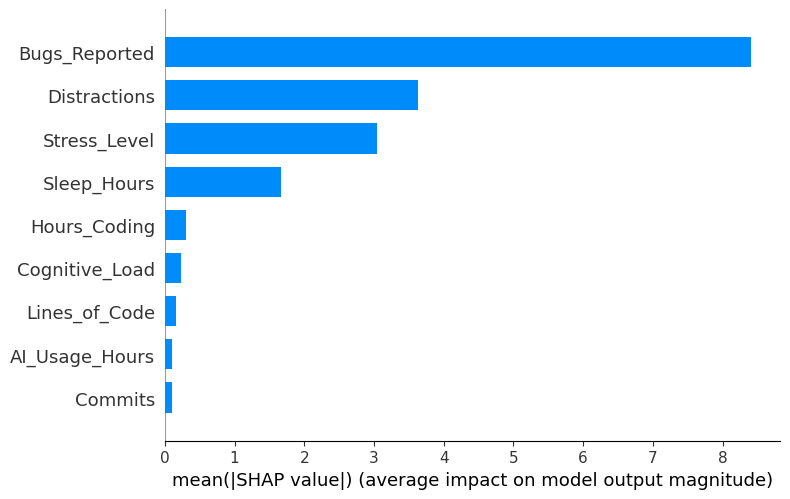

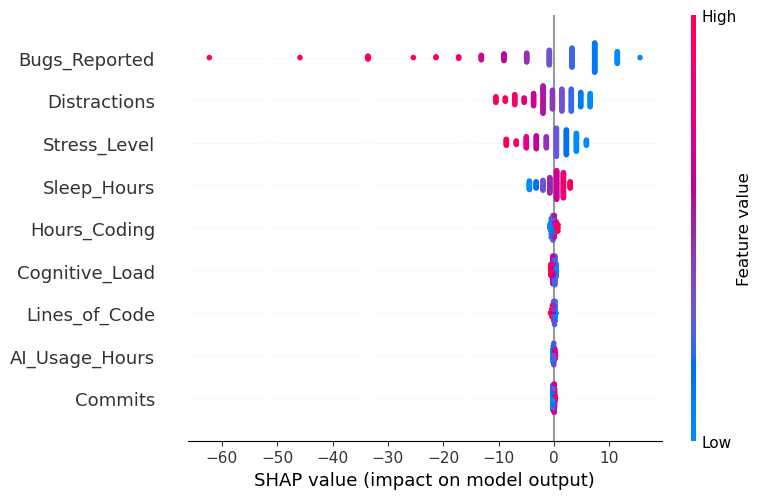

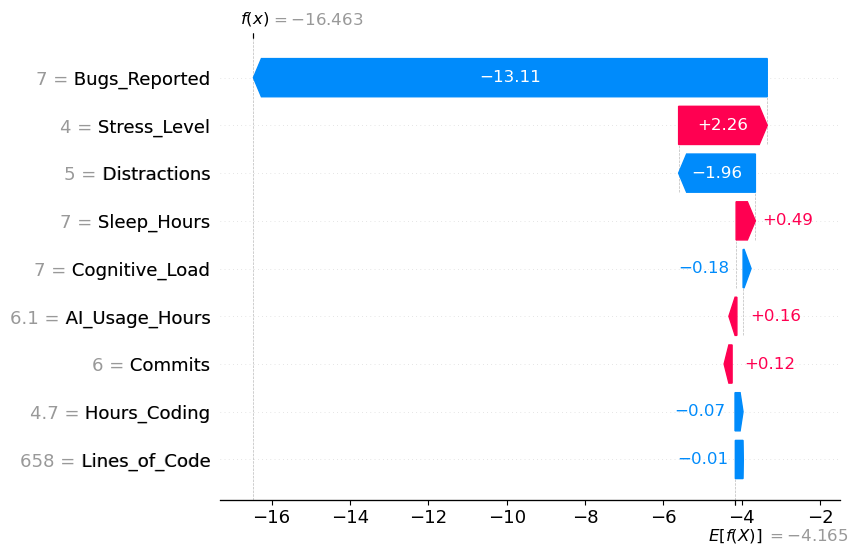

In [32]:
# pip install shap
import shap

# LinearExplainer is fast for logistic regression
explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_val)

# Global: which features matter most overall?
shap.summary_plot(shap_values, X_val, plot_type='bar')

# Dot plot: direction + magnitude + distribution across all rows
shap.summary_plot(shap_values, X_val)

# Local: why did the model predict 1 for this specific row?
row_idx = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values[row_idx],
    base_values=explainer.expected_value,
    data=X_val.iloc[row_idx],
    feature_names=X_val.columns.tolist()
))